# Trabajo Práctico Integrador: Análisis de Desempeño y Gestión de Estudiantes 🎓
**Materia:** Análisis de Datos Inicial  
**Carrera:** Tecnicatura Universitaria en Programación (TUP)

**Integrantes del grupo:**
1. Cristian Krahulik
2. Tomas Mastropietro
3. Juan Segura
4. Lautaro Castillo

---

## Hito 1: Elección y Planteo 🎯

**Dataset elegido:** `Student Performance and Behaviour.csv` (Trabajando sobre `dataset_DIRTY.csv` para la fase de limpieza).

**Descripción del Dataset:**
Este conjunto de datos contiene registros detallados de estudiantes universitarios, integrando variables académicas, demográficas y socioeconómicas. Cuenta con información sobre:
*   **Factores Académicos:** GPA previo, horas de estudio semanales, tasa de asistencia, materias falladas y notas de exámenes (parcial y final).
*   **Factores de Estilo de Vida:** Horas de sueño, niveles de estrés, uso de redes sociales y participación en actividades extracurriculares.
*   **Entorno y Contexto:** Calidad de conexión a internet, calidad del espacio de estudio, nivel educativo de los padres y nivel de ingresos familiar.
*   **Factores Psicológicos:** Puntuaciones de motivación y autoeficacia.

**Objetivos del Análisis (Preguntas a responder):**
1.  **Sobre el Riesgo Académico:** ¿En qué medida el agotamiento físico y mental —representado por altos niveles de estrés y pocas horas de sueño— anula el beneficio del esfuerzo académico, prediciendo un bajo rendimiento en el examen final independientemente de cuánto tiempo dedique el alumno a estudiar?
2.  **Sobre la Brecha Digital:** ¿Cómo condiciona la calidad de la conexión a internet la efectividad de las horas de estudio semanales? ¿Existe un punto crítico en la conectividad por debajo del cual el esfuerzo del estudiante deja de verse reflejado en sus calificaciones?
3.  **Sobre Comportamientos Atípicos:** ¿Qué hábitos diferencian a los estudiantes con éxito por estudio autónomo (aquellos con baja asistencia pero notas sobresalientes) de los estudiantes con ansiedad ante los exámenes (que dedican muchísimas horas al estudio pero obtienen resultados muy bajos)?

In [9]:
# Importación de librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os
import json

# Añadimos el directorio raíz al path para poder importar desde 'src'
sys.path.append(os.path.abspath(os.path.join('..')))

# Configuración visual básica para los gráficos
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

---
## Hito 2: ETL y Calidad de Datos 🧹

En esta fase realizamos un proceso avanzado de **Auditoría -> Limpieza -> Normalización -> Feature Engineering**.
Utilizamos un módulo externo `src/etl.py` para asegurar la consistencia del motor de datos.

In [10]:
from src.etl import auditar_datos

# 1. Carga del dataset con ruido
path_sucio = os.path.join('..', 'data', 'dataset_DIRTY.csv')
df_crudo = pd.read_csv(path_sucio)

# 2. Auditoría Inicial
reporte_inicial = auditar_datos(df_crudo)
print("=== REPORTE DE AUDITORÍA (DATASET SUCIO) ===")
print(json.dumps(reporte_inicial, indent=4, ensure_ascii=False))

print("\nVisualización rápida de inconsistencias (GPA negativo o Edades imposibles):")
cols_interes = ['Student_ID', 'Age', 'Previous_GPA', 'Weekly_Study_Hours']
display(df_crudo[(df_crudo['Previous_GPA'] < 0) | (df_crudo['Age'] > 100)].head(5)[cols_interes])

=== REPORTE DE AUDITORÍA (DATASET SUCIO) ===
{
    "total_filas": 500100,
    "duplicados": 100,
    "columnas_con_nulos": {
        "Previous_GPA": 10001,
        "Weekly_Study_Hours": 5002,
        "Attendance_Rate": 5001
    },
    "outliers": {
        "edad_invalida": 100,
        "gpa_invalido": 50,
        "horas_estudio_imposibles": 30
    },
    "valores_negativos_genericos": {
        "Previous_GPA": 50
    }
}

Visualización rápida de inconsistencias (GPA negativo o Edades imposibles):


,Student_ID,Age,Previous_GPA,Weekly_Study_Hours
1197,234739,150,2.58,2.0
13042,428636,150,2.40,19.2
18663,176891,26,-5.00,16.9
31246,456966,22,-5.00,20.8
33479,174766,150,3.58,23.7


### Aplicación de Limpieza e Ingeniería de Variables
Ejecutamos el motor de ETL que normaliza strings y crea nuevas variables diagnósticas.

In [11]:
from src.etl import limpiar_datos, crear_caracteristicas

# 3. Ejecución de la Limpieza y Normalización
df_clean = limpiar_datos(df_crudo)

# 4. Feature Engineering (Creación de nuevas variables)
df_final = crear_caracteristicas(df_clean)

# 5. Verificación Final
reporte_final = auditar_datos(df_final)
print("=== REPORTE DE AUDITORÍA (DATASET FINAL) ===")
print(json.dumps(reporte_final, indent=4, ensure_ascii=False))

print("\nNuevas variables creadas para el análisis:")
display(df_final[['Eficiencia_Estudio', 'Indice_Desgaste', 'Alerta_Riesgo']].head())

# Guardamos el resultado final
path_clean = os.path.join('..', 'data', 'dataset_CLEAN.csv')
df_final.to_csv(path_clean, index=False)
print(f"\n✅ Dataset limpio y enriquecido guardado en: {path_clean}")

=== REPORTE DE AUDITORÍA (DATASET FINAL) ===
{
    "total_filas": 500000,
    "duplicados": 0,
    "columnas_con_nulos": {},
    "outliers": {
        "edad_invalida": 0,
        "gpa_invalido": 0,
        "horas_estudio_imposibles": 0
    },
    "valores_negativos_genericos": {}
}

Nuevas variables creadas para el análisis:


,Eficiencia_Estudio,Indice_Desgaste,Alerta_Riesgo
0,3.368098,0.900000,False
1,3.925466,0.557143,False
2,3.021978,1.197368,False
3,3.380645,0.478873,True
4,2.871212,0.686275,False



✅ Dataset limpio y enriquecido guardado en: ..\data\dataset_CLEAN.csv


---
## Hito 3: Análisis y Visualización 📊

Es momento de explorar los datos visualmente y responder a las preguntas planteadas en el Hito 1 utilizando el dataset limpio `df_final`.

In [12]:
# Estadística Descriptiva General
df_final.describe()

,Student_ID,Semester_ID,Age,Family_Size,Internet_Quality,Study_Space_Quality,Previous_GPA,Number_of_Failed_Courses,Total_Credits_Earned,Weekly_Study_Hours,Attendance_Rate,Library_Visits_Per_Month,Extracurricular_Hours,Sleep_Hours,Social_Media_Usage_Hours,Stress_Level,Motivation_Score,Self_Efficacy_Score,Midterm_Mark,Final_Exam_Score,Eficiencia_Estudio,Indice_Desgaste
count,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000,500000.000000
mean,250000.500000,4.500100,23.490720,5.002176,6.565998,6.453566,2.788636,1.334232,67.501920,18.157505,79.626512,9.224000,3.984422,6.800725,2.948750,5.520213,5.987168,4.539254,53.763787,57.570266,4.191359,0.826571
std,144337.711635,2.292028,4.025972,2.001290,2.187664,2.077266,0.667427,1.487346,35.840162,7.872297,13.131068,3.712289,3.972895,1.199408,2.778273,1.970166,1.947749,1.486886,10.395511,11.309997,3.597159,0.340007
min,1.000000,1.000000,17.000000,2.000000,1.000000,1.000000,0.000000,0.000000,12.000000,2.000000,0.000000,0.000000,0.000000,3.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.090090
25%,125000.750000,2.000000,20.000000,3.000000,5.100000,5.000000,2.340000,0.000000,36.000000,12.700000,72.700000,7.000000,1.100000,6.000000,0.900000,4.200000,4.600000,3.520000,46.800000,50.400000,2.551282,0.591549
50%,250000.500000,5.000000,23.000000,5.000000,6.700000,6.500000,2.800000,1.000000,68.000000,18.100000,81.900000,9.000000,2.800000,6.800000,2.100000,5.500000,6.000000,4.540000,53.600000,57.600000,3.181319,0.800000
75%,375000.250000,6.000000,27.000000,7.000000,8.200000,8.000000,3.260000,2.000000,96.000000,23.400000,89.200000,12.000000,5.500000,7.600000,4.200000,6.900000,7.400000,5.550000,60.500000,64.800000,4.271692,1.031250
max,500000.000000,8.000000,30.000000,8.000000,10.000000,10.000000,4.000000,10.000000,144.000000,40.000000,100.000000,24.000000,30.000000,11.000000,12.000000,10.000000,10.000000,10.000000,100.000000,100.000000,47.619048,3.225806


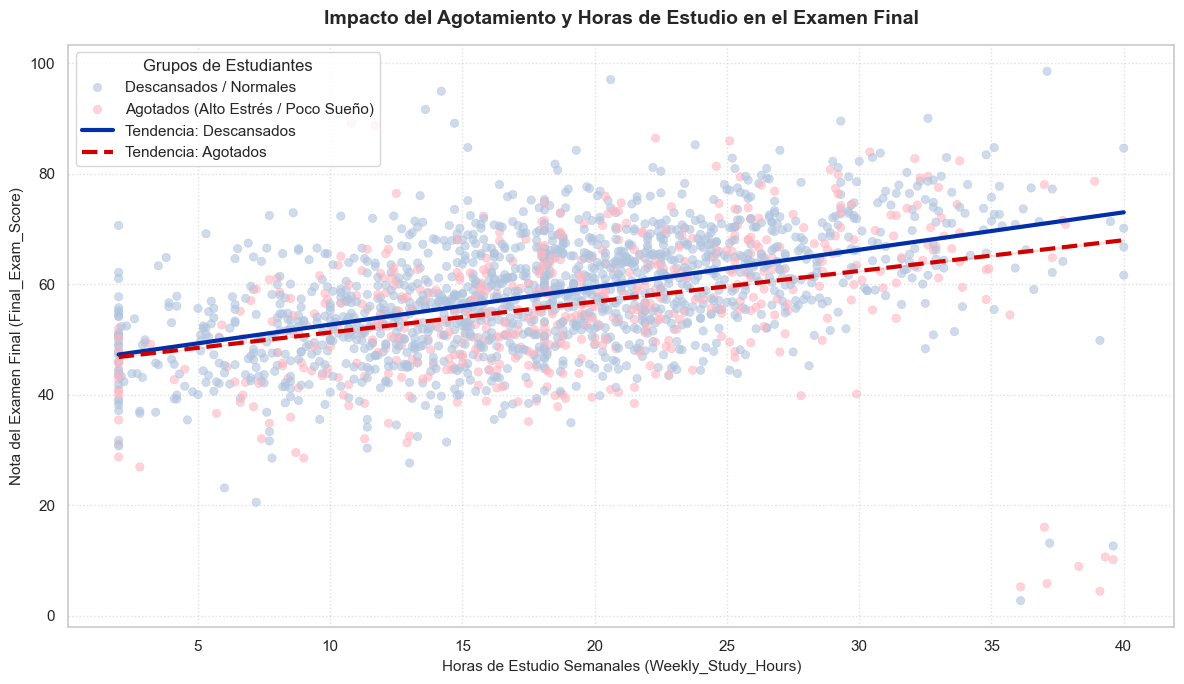

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carga de datos
df = pd.read_csv(os.path.join('..', 'data', 'dataset_CLEAN.csv'))  # Cambia el nombre si es necesario

# Definir los promedios y crear los grupos
# Calculamos los promedios usando los 50.000 datos para máxima precisión
promedio_estres = df['Stress_Level'].mean()
promedio_sueno = df['Sleep_Hours'].mean()

# Creamos una regla: Condición de agotamiento (estrés alto Y sueño bajo)
condicion_agotado = (df['Stress_Level'] > promedio_estres) & (df['Sleep_Hours'] < promedio_sueno)

# Creamos la nueva columna. Por defecto todos son 'Descansados/Normales'
df['Estado_Agotamiento'] = 'Descansados / Normales'
# A los que cumplen la condición, los etiquetamos como 'Agotados (Alto Estrés / Poco Sueño)'
df.loc[condicion_agotado, 'Estado_Agotamiento'] = 'Agotados (Alto Estrés / Poco Sueño)'

# Tomar la muestra aleatoria para el gráfico
# Guardamos una muestra de 2000 filas para que los puntos no tapen las líneas
df_muestra = df.sample(n=2000, random_state=42)

# Construcción del gráfico
# Seteamos el tamaño de la ventana del gráfico
plt.figure(figsize=(12, 7))

# 1. Dibujamos los puntos (Scatter Plot) usando la muestra de 2000 datos
# Usamos un alpha bajo (0.2) para que los puntos sean semi-transparentes y queden de fondo
sns.scatterplot(
    data=df_muestra, 
    x='Weekly_Study_Hours', 
    y='Final_Exam_Score', 
    hue='Estado_Agotamiento',
    palette={'Descansados / Normales': '#B0C4DE', 'Agotados (Alto Estrés / Poco Sueño)': '#FFB6C1'}, # Gris azulado y Rosa suave
    alpha=0.6,
    edgecolor=None
)

# 2. Dibujamos las líneas de tendencia usando los 50.000 datos completos
# Esto asegura que la línea represente la realidad absoluta del dataset
sns.regplot(
    data=df[df['Estado_Agotamiento'] == 'Descansados / Normales'],
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    scatter=False, 
    label='Tendencia: Descansados',
    color='#002FA7', 
    line_kws={'linewidth': 3, 'linestyle': '-'} 
)

sns.regplot(
    data=df[df['Estado_Agotamiento'] == 'Agotados (Alto Estrés / Poco Sueño)'],
    x='Weekly_Study_Hours',
    y='Final_Exam_Score',
    scatter=False,
    label='Tendencia: Agotados',
    color='#D10000', 
    line_kws={'linewidth': 3, 'linestyle': '--'} 
)

# Estética y etiquetas del gráfico
plt.title('Impacto del Agotamiento y Horas de Estudio en el Examen Final', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Horas de Estudio Semanales (Weekly_Study_Hours)', fontsize=11)
plt.ylabel('Nota del Examen Final (Final_Exam_Score)', fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6) # Una grilla sutil de fondo
plt.legend(title='Grupos de Estudiantes', loc='upper left')

# Mostramos el gráfico en pantalla
plt.tight_layout()
plt.show()

---
## Hito 4: Interfaz Gráfica (Dashboard) 🖥️

El diferencial técnico del proyecto. Se debe presentar un dashboard interactivo utilizando Streamlit que permita al usuario filtrar los datos en tiempo real.

### 🛠️ Especificaciones Técnicas
1.  **Interactividad:** Widgets para filtrar por comisiones, carreras o niveles de riesgo.
2.  **KPIs:** Métricas de aprobación y promedios generales actualizables.
3.  **Visualización:** Gráficos dinámicos basados en los filtros seleccionados.

*Nota: La aplicación se encuentra en el archivo `app.py` o dentro de la carpeta `src/`. Para ejecutarla use `streamlit run app.py`.*

---
## Hito 5: Informe de Gestión y Propuestas 🚀

Basados en la evidencia recolectada, completen el diagnóstico final:

### 1. Diagnóstico Académico
*¿Qué historias cuentan los datos?*

### 2. Propuestas de Mejora (Justificadas)
* **Propuesta A:** [Acción]
* **Propuesta B:** [Acción]

### 3. Conclusión Final
*Impacto esperado de las propuestas.*